# Fortune 500 Growth & Performance Analysis
### Exploratory Data Analysis, Statistical Testing, Forecasting & Segmentation

**Stack:** Python (Pandas, NumPy, SciPy, Statsmodels, scikit-learn, Prophet), SQL (SQLite), Plotly

This notebook is the analytical backbone behind the Streamlit dashboard (`app.py` + `pages/`).
It walks through the same methodology an analyst would use in Excel — trend lines, YoY growth,
correlation — but scaled across 500 companies x 10 fiscal years x 10 sectors, with statistical
significance testing and machine-learning-based segmentation layered on top.

**Sections**
1. Data loading & sanity checks
2. Descriptive statistics & Excel-style KPI rollups
3. Sector-level growth & margin trends
4. Statistical trend significance testing (OLS)
5. Correlation analysis
6. Time-series forecasting (ARIMA vs. Prophet)
7. KMeans performance clustering
8. Isolation Forest anomaly detection
9. Key findings summary


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from utils.analytics import (
    compute_cagr, sector_summary, linear_trend_stats,
    forecast_arima, forecast_prophet, cluster_companies,
    detect_anomalies, correlation_matrix,
)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 1. Data Loading & Sanity Checks

Load from the SQLite panel (built by `data/generate_data.py`).

In [2]:
conn = sqlite3.connect('../data/fortune500_panel.db')
df = pd.read_sql('SELECT * FROM fortune500', conn)
conn.close()

print(f"Shape: {df.shape}")
print(f"Years: {df.fiscal_year.min()}-{df.fiscal_year.max()}")
print(f"Companies: {df.company_id.nunique()}, Sectors: {df.sector.nunique()}")
df.head()


Shape: (5000, 17)
Years: 2014-2023
Companies: 500, Sectors: 10


,company_id,company_name,sector,hq_state,founded_year,fiscal_year,revenue_musd,net_income_musd,net_margin_pct,employees,rd_spend_musd,market_cap_musd,total_assets_musd,revenue_growth_pct,fortune500_rank,roa_pct,revenue_per_employee_k
0,C0001,Horizon Labs,Energy,CT,1903,2014,"261,598.50","16,291.10",6.23,2010290,"7,720.30","527,240.90","688,097.40",-5.15,71,2.37,130.10
1,C0001,Horizon Labs,Energy,CT,1903,2015,"273,634.40","-7,877.70",-2.88,2132940,"4,026.90","264,495.10","377,416.40",4.60,71,-2.09,128.30
2,C0001,Horizon Labs,Energy,CT,1903,2016,"327,324.60","-2,953.00",-0.90,2403239,"2,295.80","755,235.60","594,606.40",19.62,59,-0.50,136.20
3,C0001,Horizon Labs,Energy,CT,1903,2017,"373,499.80","-29,687.90",-7.95,2902023,"5,870.20","904,873.00","1,174,234.70",14.11,50,-2.53,128.70
4,C0001,Horizon Labs,Energy,CT,1903,2018,"316,283.10","-39,665.30",-12.54,2560423,"3,657.30","667,701.90","696,698.10",-15.32,79,-5.69,123.50


In [3]:
# Missing value / integrity check
print(df.isna().sum().sum(), "missing values")
assert df.groupby('company_id').fiscal_year.nunique().eq(10).all(), "every company should have 10 years"
print("Integrity check passed: every company has a full 10-year history.")


0 missing values
Integrity check passed: every company has a full 10-year history.


## 2. Descriptive Statistics & Excel-Style KPI Rollups

These are the numbers that would normally live in a pivot table: total revenue, net income, average margin, and headcount, for the most recent fiscal year.

In [4]:
latest_year = df.fiscal_year.max()
latest = df[df.fiscal_year == latest_year]

kpis = {
    'Total Revenue ($B)': latest.revenue_musd.sum() / 1000,
    'Total Net Income ($B)': latest.net_income_musd.sum() / 1000,
    'Revenue-Weighted Avg Margin (%)': latest.net_income_musd.sum() / latest.revenue_musd.sum() * 100,
    'Total Employees (M)': latest.employees.sum() / 1_000_000,
    'Median Company Revenue ($M)': latest.revenue_musd.median(),
}
pd.Series(kpis).to_frame('Value')


,Value
Total Revenue ($B),"115,911.23"
Total Net Income ($B),"11,681.21"
Revenue-Weighted Avg Margin (%),10.08
Total Employees (M),675.08
Median Company Revenue ($M),"140,981.95"


In [5]:
df.groupby('fiscal_year').agg(
    total_revenue_musd=('revenue_musd', 'sum'),
    avg_margin_pct=('net_margin_pct', 'mean'),
    avg_growth_pct=('revenue_growth_pct', 'mean'),
).round(2)


,total_revenue_musd,avg_margin_pct,avg_growth_pct
fiscal_year,,,
2014,"65,042,265.60",11.43,6.36
2015,"67,148,617.50",11.26,4.01
2016,"70,611,520.20",11.39,5.93
2017,"75,955,833.40",11.17,7.96
2018,"82,664,151.70",11.37,8.86
2019,"88,601,772.80",11.19,6.53
2020,"85,198,433.80",11.34,-3.88
2021,"97,242,527.90",11.49,14.11
2022,"107,111,771.80",11.15,9.53


## 3. Sector-Level Growth & Margin Trends

In [6]:
sec_summary = sector_summary(df, latest_year)
sec_summary


,sector,num_companies,total_revenue_musd,avg_net_margin_pct,revenue_weighted_margin_pct,avg_yoy_growth_pct,total_employees
7,Retail,86.00,"42,216,899.60",5.30,5.76,5.92,"245,381,714.00"
8,Technology,65.00,"20,328,868.10",18.42,18.44,15.90,"109,502,502.00"
2,Energy,62.00,"17,608,117.30",4.90,5.07,5.63,"109,221,347.00"
3,Financial Services,75.00,"9,964,177.20",21.03,20.97,7.61,"58,097,521.00"
4,Health Care,61.00,"9,713,779.60",13.30,13.75,8.43,"55,719,557.00"
0,Automotive,26.00,"5,776,409.40",4.81,3.31,4.58,"35,669,271.00"
5,Industrials,39.00,"3,370,561.80",9.18,9.82,5.47,"19,565,941.00"
1,Consumer Goods,35.00,"2,615,651.70",10.88,10.56,4.46,"15,552,547.00"
9,Telecom,23.00,"2,612,306.80",9.93,9.56,2.24,"15,848,897.00"
6,Materials,28.00,"1,704,457.20",7.27,8.01,5.43,"10,520,057.00"


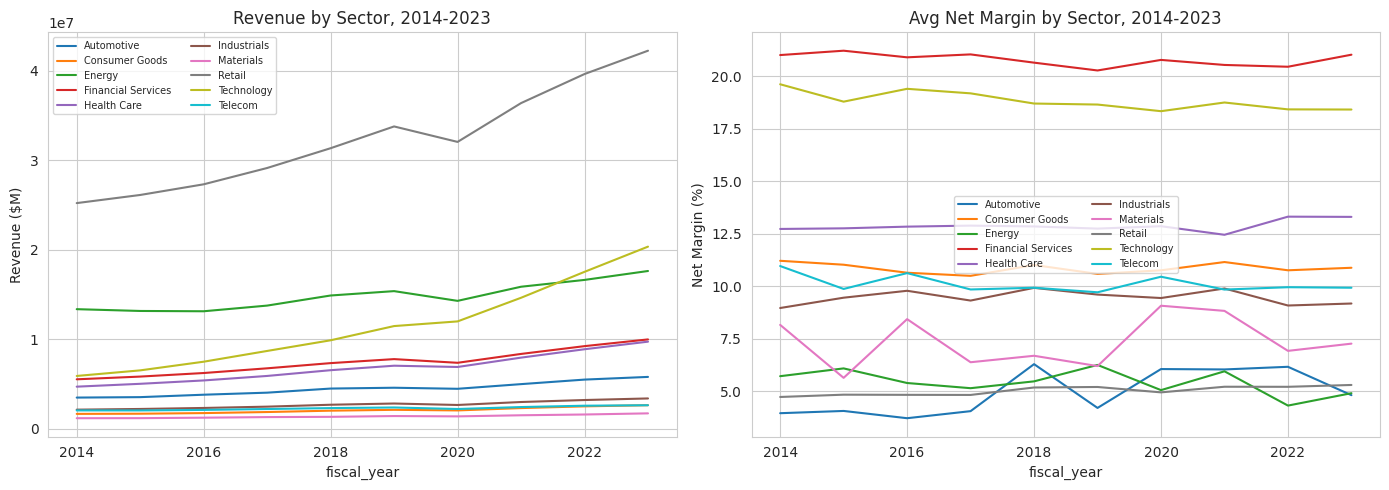

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

trend = df.groupby(['fiscal_year', 'sector'])['revenue_musd'].sum().unstack()
trend.plot(ax=axes[0], linewidth=1.5)
axes[0].set_title('Revenue by Sector, 2014-2023')
axes[0].set_ylabel('Revenue ($M)')
axes[0].legend(fontsize=7, ncol=2)

margin_trend = df.groupby(['fiscal_year', 'sector'])['net_margin_pct'].mean().unstack()
margin_trend.plot(ax=axes[1], linewidth=1.5)
axes[1].set_title('Avg Net Margin by Sector, 2014-2023')
axes[1].set_ylabel('Net Margin (%)')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


## 4. Statistical Trend Significance Testing (OLS)

For each sector, fit `revenue ~ year` and test whether the slope is significantly different from zero (p < 0.05). This distinguishes a genuine structural trend from year-to-year noise — the same question `=SLOPE()` / `=LINEST()` answers in Excel, run here programmatically across every sector at once.

In [8]:
rows = []
for s in df.sector.unique():
    series = df[df.sector == s].groupby('fiscal_year')['revenue_musd'].sum().sort_index()
    res = linear_trend_stats(series)
    rows.append({'sector': s, **res, 'significant': res['p_value'] < 0.05})

trend_df = pd.DataFrame(rows).sort_values('slope', ascending=False)
trend_df


,sector,slope,r2,p_value,significant
8,Retail,"1,844,342.61",0.95,0.00,True
5,Technology,"1,541,033.21",0.94,0.00,True
3,Health Care,"536,467.88",0.96,0.00,True
0,Energy,"475,367.87",0.86,0.00,True
2,Financial Services,"465,813.40",0.95,0.00,True
6,Automotive,"253,327.44",0.95,0.00,True
1,Industrials,"135,095.91",0.95,0.00,True
4,Consumer Goods,"108,521.19",0.95,0.00,True
9,Telecom,"64,105.41",0.88,0.00,True
7,Materials,"57,035.45",0.94,0.00,True


**Interpretation:** sectors with `significant = True` and a positive slope have a statistically defensible growth trend over the decade (not just a lucky year); sectors with high p-values have revenue trajectories that are statistically indistinguishable from flat, even if the raw numbers wiggle.

## 5. Correlation Analysis

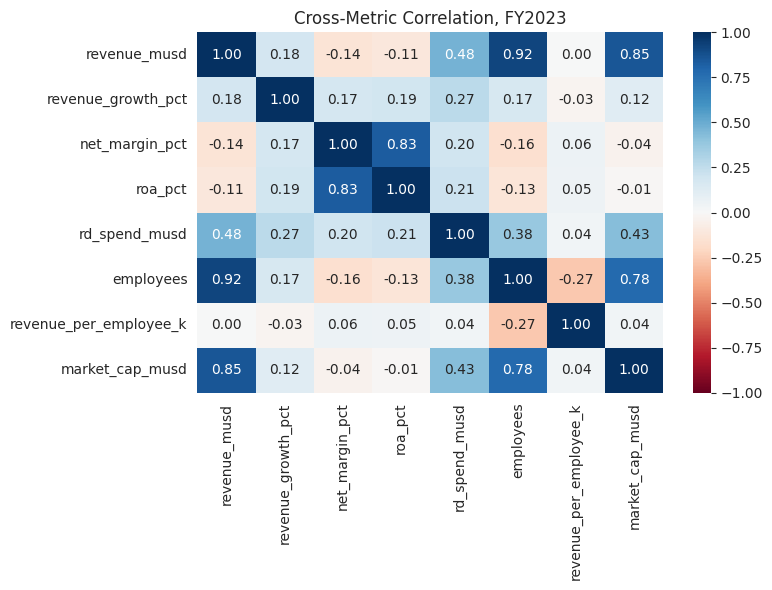

In [9]:
corr = correlation_matrix(df, latest_year)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', center=0, vmin=-1, vmax=1)
plt.title(f'Cross-Metric Correlation, FY{latest_year}')
plt.tight_layout()
plt.show()


## 6. Time-Series Forecasting: ARIMA vs. Prophet

Two independent models on total panel revenue, cross-checked against each other. Divergence between the two flags where the forecast is model-sensitive rather than robust.

In [10]:
market_series = df.groupby('fiscal_year')['revenue_musd'].sum().sort_index()

arima_fc = forecast_arima(market_series, periods=3)
prophet_fc = forecast_prophet(market_series, periods=3)

print("ARIMA forecast:")
display(arima_fc)
print("\nProphet forecast:")
display(prophet_fc)


09:32:58 - cmdstanpy - INFO - Chain [1] start processing


09:32:58 - cmdstanpy - INFO - Chain [1] done processing


ARIMA forecast:


,fiscal_year,forecast_musd,lower_95_musd,upper_95_musd
0,2024,"121,339,955.06","108,766,629.63","133,913,280.50"
1,2025,"126,754,412.73","108,564,616.34","144,944,209.12"
2,2026,"132,154,639.20","109,386,925.29","154,922,353.11"



Prophet forecast:


,fiscal_year,forecast_musd,lower_95_musd,upper_95_musd
0,2024,"115,712,753.14","108,251,006.82","122,583,734.55"
1,2025,"121,196,282.65","114,460,421.28","128,114,018.51"
2,2026,"126,679,812.17","119,475,321.80","133,711,790.49"


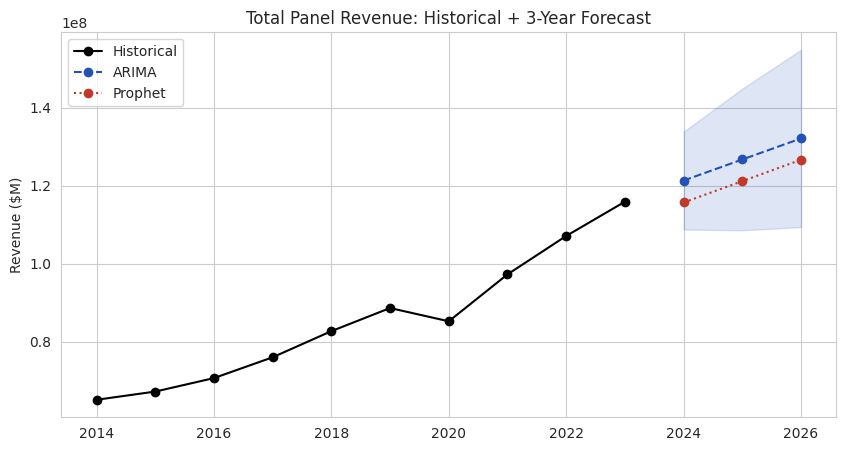

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(market_series.index, market_series.values, marker='o', label='Historical', color='black')
plt.plot(arima_fc.fiscal_year, arima_fc.forecast_musd, marker='o', linestyle='--', label='ARIMA', color='#2451B7')
plt.fill_between(arima_fc.fiscal_year, arima_fc.lower_95_musd, arima_fc.upper_95_musd, alpha=0.15, color='#2451B7')
plt.plot(prophet_fc.fiscal_year, prophet_fc.forecast_musd, marker='o', linestyle=':', label='Prophet', color='#C0392B')
plt.legend()
plt.title('Total Panel Revenue: Historical + 3-Year Forecast')
plt.ylabel('Revenue ($M)')
plt.show()


## 7. KMeans Performance Clustering

Segment companies into performance archetypes using growth, margin, ROA, and revenue-per-employee — features standardized before clustering so no single metric dominates purely due to scale.

In [12]:
clustered, centroids, labels = cluster_companies(df, latest_year, k=4)
print("Cluster labels:", labels)
centroids


Cluster labels: {0: 'High growth, high margin', 1: 'High growth, low margin', 2: 'Low growth, high margin', 3: 'Low growth, low margin'}


,revenue_growth_pct,net_margin_pct,roa_pct,revenue_per_employee_k
0,16.84,21.90,13.79,210.92
1,9.33,2.79,1.25,158.94
2,3.27,14.09,7.26,153.45
3,2.32,8.49,4.29,301.05


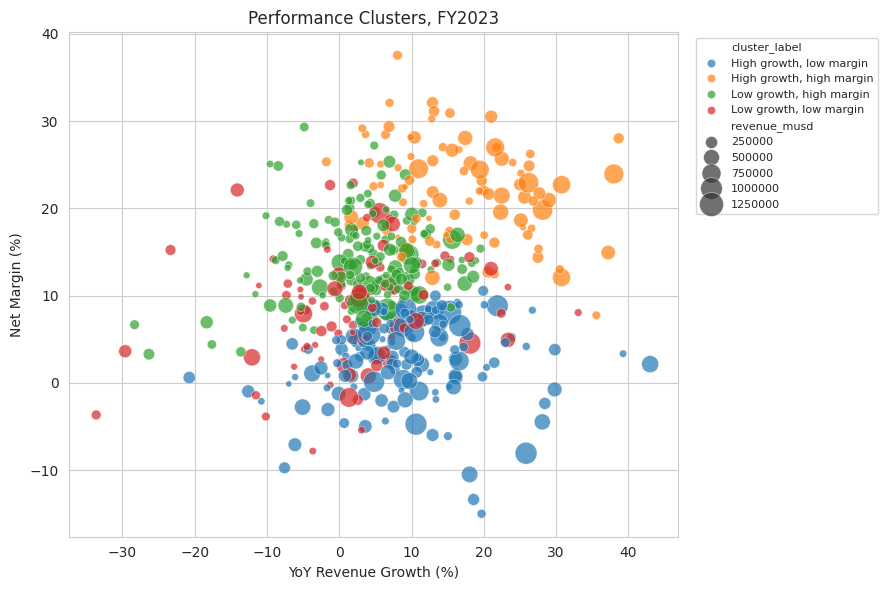

In [13]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=clustered, x='revenue_growth_pct', y='net_margin_pct',
                 hue='cluster_label', size='revenue_musd', sizes=(20, 300), alpha=0.7)
plt.title(f'Performance Clusters, FY{latest_year}')
plt.xlabel('YoY Revenue Growth (%)')
plt.ylabel('Net Margin (%)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


In [14]:
pd.crosstab(clustered.cluster_label, clustered.sector)


sector,Automotive,Consumer Goods,Energy,Financial Services,Health Care,Industrials,Materials,Retail,Technology,Telecom
cluster_label,,,,,,,,,,
"High growth, high margin",0,2,6,34,14,0,0,0,37,0
"High growth, low margin",13,6,28,1,8,10,13,50,7,6
"Low growth, high margin",6,18,15,34,28,18,9,16,16,11
"Low growth, low margin",7,9,13,6,11,11,6,20,5,6


## 8. Isolation Forest Anomaly Detection

Flags companies whose combination of growth, margin, ROA, and efficiency is statistically unusual relative to the full population — useful both for spotting breakout performers and for early red-flag detection.

In [15]:
anomalies = detect_anomalies(df, latest_year, contamination=0.05)
flagged = anomalies[anomalies.anomaly_flag]
print(f"{len(flagged)} companies flagged out of {len(anomalies)} evaluated")
flagged[['company_name', 'sector', 'revenue_growth_pct', 'net_margin_pct', 'anomaly_severity']].head(15)


25 companies flagged out of 500 evaluated


,company_name,sector,revenue_growth_pct,net_margin_pct,anomaly_severity
889,Metro Systems,Financial Services,8.05,37.55,0.14
1299,Compass Motors,Technology,38.66,28.03,0.10
2079,Vertex Networks,Energy,18.58,-13.36,0.10
49,Global Dynamics,Energy,18.03,-10.48,0.10
4099,Pinnacle Partners,Financial Services,12.78,30.26,0.09
959,Alliance Dynamics,Technology,21.01,30.52,0.09
3899,Prime Motors,Energy,19.68,-15.00,0.08
2729,Frontier Solutions,Technology,37.99,23.95,0.07
4149,Quantum Foods,Energy,-33.63,-3.67,0.06
3919,Orbit Group,Energy,-23.35,15.23,0.05


## 9. Key Findings Summary

- Sector rollups (Section 2-3) show which sectors compounded revenue fastest over the decade, and which margins expanded vs. compressed.
- OLS trend testing (Section 4) separates statistically real growth trends from noisy ones.
- Correlation analysis (Section 5) quantifies how growth, margin, R&D intensity, and efficiency move together.
- ARIMA/Prophet forecasts (Section 6) project the next 3 fiscal years with uncertainty bands.
- Clustering (Section 7) surfaces four performance archetypes analysts can use to triage 500 companies quickly.
- Anomaly detection (Section 8) is a lightweight way to flag companies worth a closer look, either as standouts or as risks.

**Next steps for a production version:** swap the synthetic panel for real filings (SEC EDGAR / Fortune's own dataset), add sentiment features from earnings-call transcripts, and retrain the forecasting models quarterly.